In [1]:
import opensim as osim
import math

# Define the model
model = osim.Model()
model.setName('torque_example')
model.setGravity(osim.Vec3(0, -9.81, 0))
ground = model.getGround()

# Define the body
m = 1.0 
J = osim.Inertia(0.1, 0.1, 0.1)
pos_com = osim.Vec3(0, 0, 0)

head = osim.Body()
head.setName('head')
head.setMass(m)
head.setInertia(J)
head.setMassCenter(pos_com)
model.addBody(head)

# Pin joint for rotation of the head
joint_name = 'head_joint'
parent_physical_frame = ground
location_in_parent = osim.Vec3(0, 1, 0)
orientation_in_parent = osim.Vec3(math.pi/2, 0, 0)
child_physical_frame = head
location_in_child = osim.Vec3(0, 0, 0)
orientation_in_child = osim.Vec3(0, 0, 0)

joint = osim.PinJoint(
    joint_name,
    parent_physical_frame,
    location_in_parent,
    orientation_in_parent,
    child_physical_frame,
    location_in_child,
    orientation_in_child
)

model.addJoint(joint)

# Define coordinate
coord = joint.updCoordinate()
coord.setName('q')
coord.setDefaultValue(0)
coord.setDefaultSpeedValue(0)

# Define CoordinateActuator
act = osim.CoordinateActuator()
act.setName('torque')
act.setCoordinate(coord)
act.setOptimalForce(1)
act.setMinControl(-1e6)
act.setMaxControl(1e6)
model.addForce(act)

# Define controller
func = osim.Constant()
ctrl = osim.PrescribedController()
ctrl.setName('controller')
ctrl.addActuator(act)
ctrl.prescribeControlForActuator('torque', func)
model.addController(ctrl)

# Finalize and initialize the model
model.finalizeConnections()
state = model.initSystem()
act.overrideActuation(state, True)

model.realizePosition(state)
model.realizeVelocity(state)
model.realizeAcceleration(state)
model.realizeDynamics(state)

# Initialize Simulation Manager
manager = osim.Manager(model)
manager.setIntegratorAccuracy(1e-6)
manager.initialize(state)

# Define simulation parameters
t = 0.0
dt = 0.01
tf = 20

print(f'Initial position:       {coord.getValue(state)} rad')
print(f'Initial speed:          {coord.getSpeedValue(state)} rad/s')
print(f'Initial acceleration:   {coord.getAccelerationValue(state)} rad/s²')
print(f'Initial torque:         {act.getActuation(state)} Nm')

Initial position:       0.0 rad
Initial speed:          0.0 rad/s
Initial acceleration:   0.0 rad/s²
Initial torque:         0.0 Nm


In [2]:
# controls = model.updControls(state)
# model.computeControls(state, controls=controls)
# model.realizeDynamics(state)
# model.realizeAcceleration(state)

In [ ]:
# act.setOverrideActuation(state, -2.0)
# act.setActuation(state, -2.0)

# model.realizeDynamics(state)
# model.realizeAcceleration(state)

# print(f'Overridden torque:       {act.getActuation(state)} Nm')
# print(f'Overridden acceleration: {coord.getAccelerationValue(state)} rad/s²')

In [4]:
t_vals = []
q_vals = []
omega_vals = []
alpha_vals = []
torque_vals = []

In [5]:
while t < tf:
    if t < 0.25 * tf:
        act.setOverrideActuation(state, -1.0)
    elif t < 0.75 * tf:
        act.setOverrideActuation(state, 1.0)
    else:
        act.setOverrideActuation(state, -1.0)

    model.realizeDynamics(state)
    model.realizeAcceleration(state)

    state = manager.integrate(t + dt)
    model.realizePosition(state)
    model.realizeVelocity(state)
    model.realizeAcceleration(state)
    model.realizeDynamics(state)

    t = state.getTime()

    t_vals.append(t)
    q_vals.append(coord.getValue(state))
    omega_vals.append(coord.getSpeedValue(state))
    alpha_vals.append(coord.getAccelerationValue(state))
    torque_vals.append(act.getActuation(state))

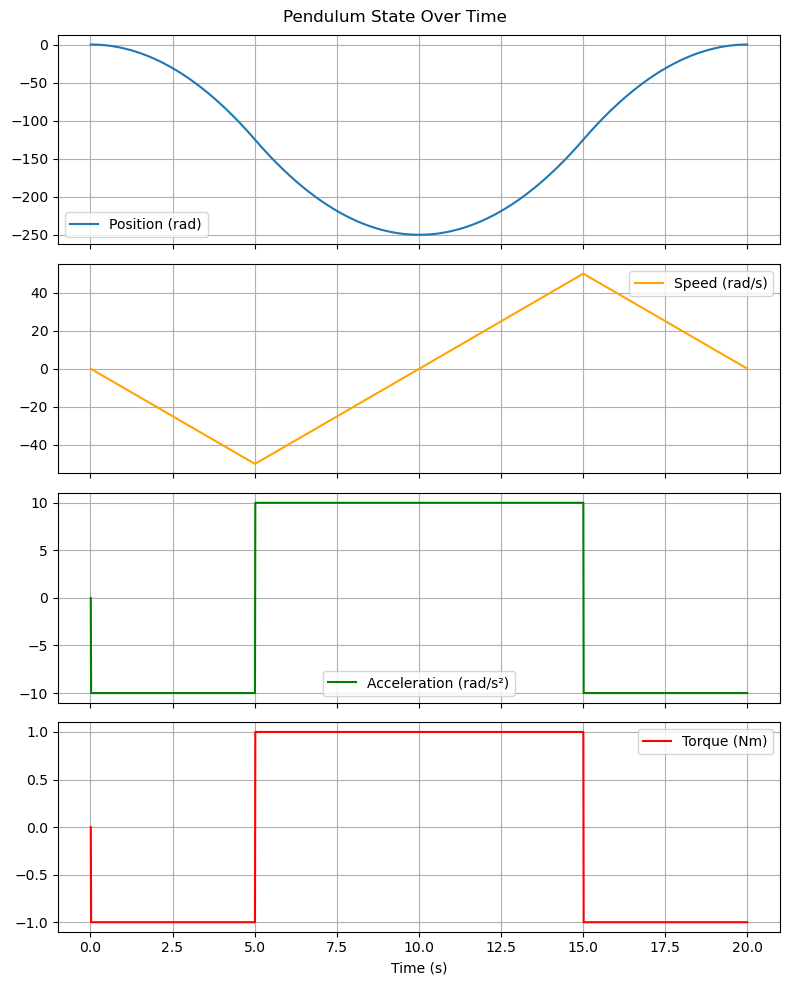

In [6]:
import matplotlib.pyplot as plt

plt.subplots(4, 1, figsize=(8, 10), sharex=True)
plt.suptitle('Pendulum State Over Time')

plt.subplot(4, 1, 1)
plt.plot(t_vals, q_vals, label='Position (rad)')
plt.grid()
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t_vals, omega_vals, label='Speed (rad/s)', color='orange')
plt.grid()
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t_vals, alpha_vals, label='Acceleration (rad/s²)', color='green')
plt.grid()
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(t_vals, torque_vals, label='Torque (Nm)', color='red')
plt.grid()
plt.legend()

plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()